[[1 1 1 1 1]
 [1 0 0 0 1]
 [1 1 1 1 1]]
[[ 4.93439239e-01  4.61603061e-02  5.17340053e-01]
 [ 1.74402998e+00 -5.22690072e-02 -2.79011884e-01]
 [ 1.81249029e+00  9.75852610e-01 -4.91538532e-01]
 [ 5.49303576e-01 -2.87606868e-01 -4.88156860e-01]
 [ 1.83017852e-01 -1.77587837e+00 -1.62529439e+00]
 [-7.96980164e-01 -8.51575049e-01  2.16218628e-01]
 [-1.21826859e+00 -1.26163023e+00  1.25601706e+00]
 [-3.86933017e-01  2.57404552e-01 -1.35421958e+00]
 [-7.75162723e-01  3.01948517e-01 -1.10699945e+00]
 [ 3.45978124e-01 -4.28463047e-01 -3.30989813e-01]
 [-8.45013279e-01  2.08943513e+00 -7.97583137e-02]
 [-1.40066567e+00  1.03242274e+00 -1.17007910e+00]
 [ 1.42686307e-01 -1.82349718e+00 -1.26701701e+00]
 [ 1.28061139e-01  9.46117052e-01  8.71885533e-02]
 [-2.52739338e-01 -1.20992939e-01 -1.40278120e+00]
 [-9.88966824e-01 -2.84754328e-01  8.87088163e-01]
 [ 3.06888192e-01 -1.62165820e+00  2.25101819e-01]
 [-5.81051242e-01 -5.06767212e-01  4.84818398e-01]
 [ 1.14447901e+00  1.14403850e+00 -8.25443

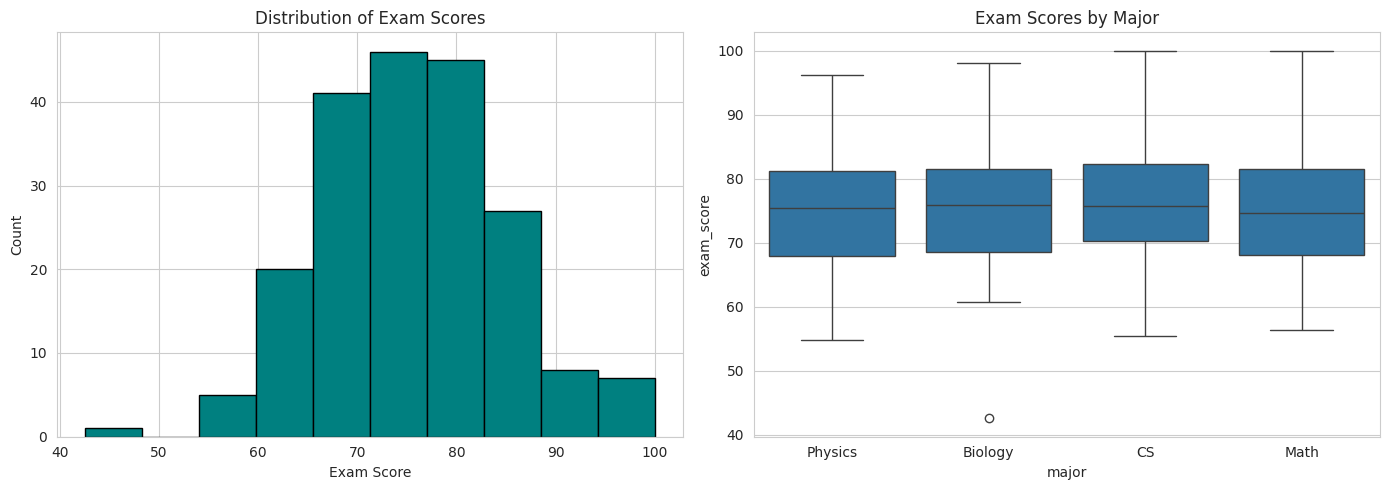

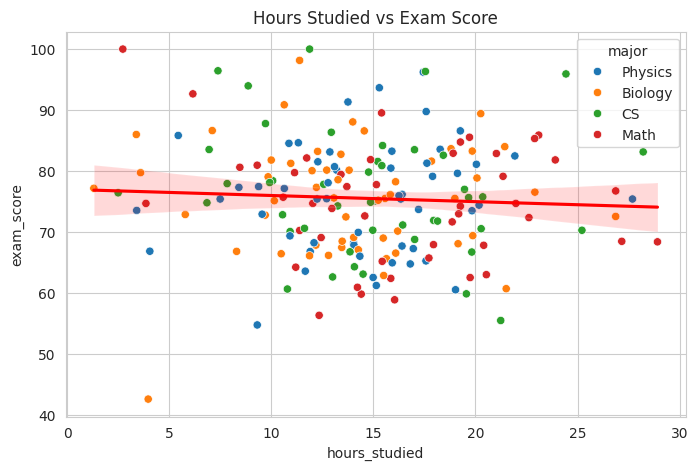

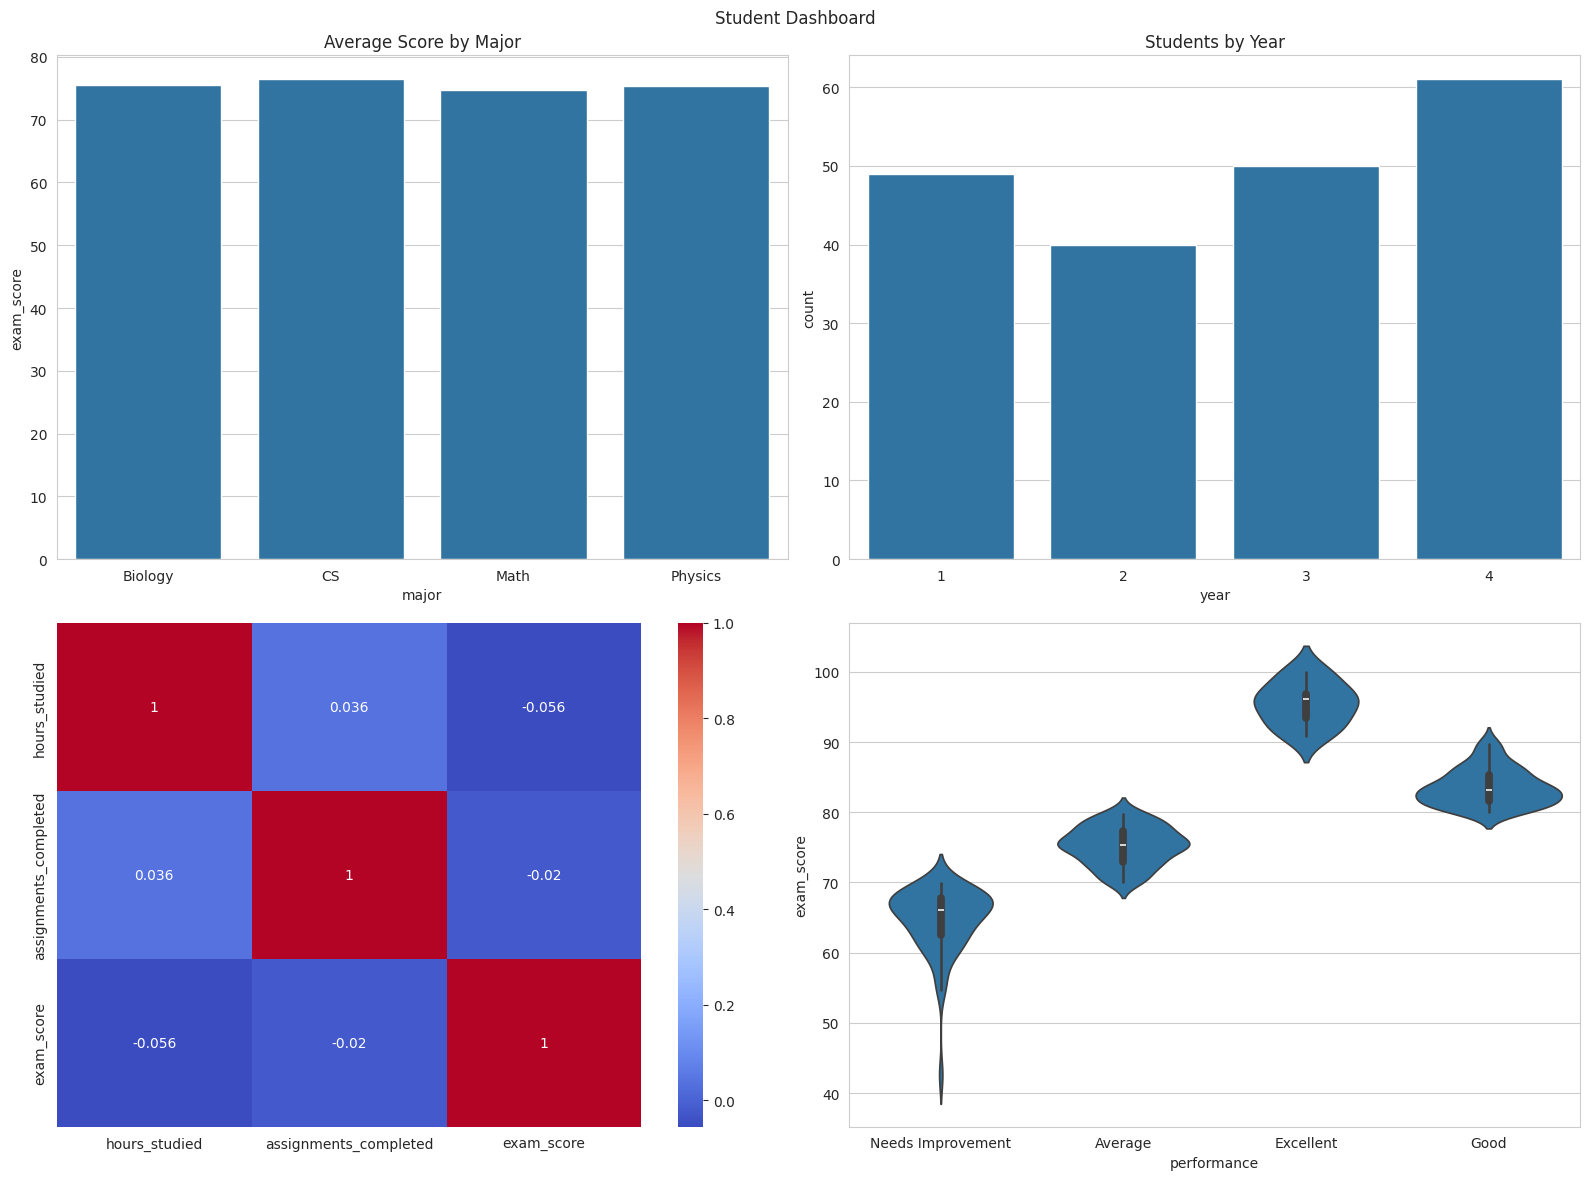


--- Age Group Analysis ---
           count        mean           sum    avg_income
age_group                                               
18-25         81  241.153717  19533.451053  50634.018330
26-35         73  235.777466  17211.755008  48747.148046
36-50        160  245.019561  39203.129763  48516.895668
51-70        186  263.166335  48948.938378  50713.163384

Top customers:
     age        income  purchase_frequency  avg_purchase_value  churn_risk  \
6    38  58876.388563                  10          110.331527    0.166667   
9    40  48809.492879                  10          110.228581    0.166667   
14   57  82648.226079                  10           81.093443    0.166667   
19   41  21282.756976                   8          119.651218    0.333333   
24   38  53981.193911                   8          120.320786    0.333333   

           clv age_group  
6   919.429388     36-50  
9   918.571506     36-50  
14  675.778695     51-70  
19  638.139832     36-50  
24  641.710857 

/tmp/ipykernel_6534/1005255680.py:184: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_analysis = customers.groupby("age_group")["clv"].agg(['count', 'mean', 'sum'])
/tmp/ipykernel_6534/1005255680.py:185: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_analysis["avg_income"] = customers.groupby("age_group")["income"].mean()


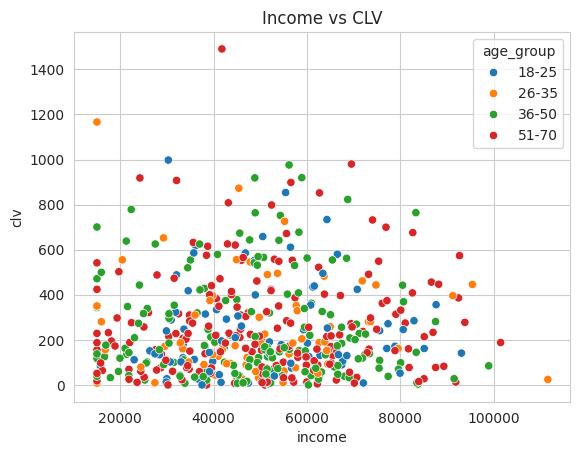

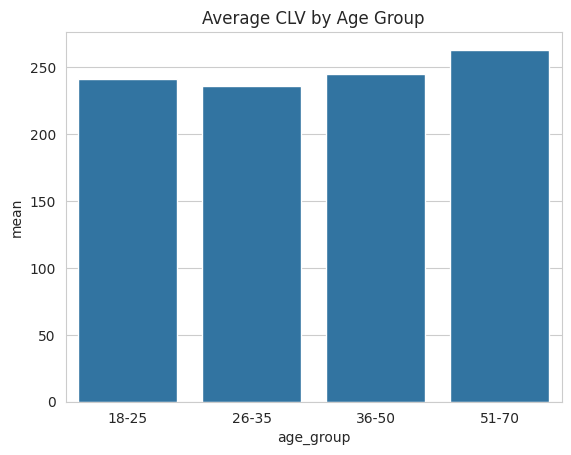

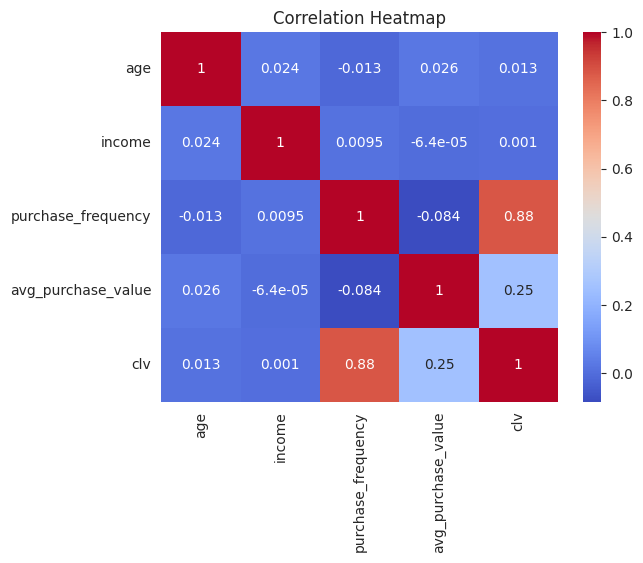

In [5]:

# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ===============================
# EXERCISE 4
# ===============================

# Task 1
arr = np.array([[1,1,1,1,1],
                [1,0,0,0,1],
                [1,1,1,1,1]])
print(arr)


# Task 2
np.random.seed(42)
random_data = np.random.randn(100, 3)

normalized = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)
print(normalized)


# Task 3: Linear Regression (Normal Equation)
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])

y = X @ true_theta + np.random.randn(50) * 0.1

X_T = X.T
theta_hat = np.linalg.inv(X_T @ X) @ X_T @ y

print("\n--- Task 3: Linear Regression via Normal Equation ---")
print(f"True Theta:      {true_theta}")
print(f"Estimated Theta: {theta_hat}")
print(f"Difference:      {np.abs(true_theta - theta_hat)}")


# ===============================
# EXERCISE 5
# ===============================

np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce missing values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan


# Task 1: Data Cleaning
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())

# Fill missing values
df['exam_score'] = df['exam_score'].fillna(
    df.groupby('major')['exam_score'].transform('mean')
)

df['hours_studied'] = df['hours_studied'].fillna(
    df.groupby('year')['hours_studied'].transform('median')
)

print("\nFilled Dataset:\n", df.head())


# Task 2: Analysis
average_score_by_major = df.groupby('major')['exam_score'].mean()
print("\nAverage exam score by major:\n", average_score_by_major)

best_major = average_score_by_major.idxmax()
print(f"Major with highest average score: {best_major}")


# Performance categorization
df['performance'] = 'Needs Improvement'

df.loc[(df['exam_score'] >= 70) & (df['exam_score'] < 80), 'performance'] = 'Average'
df.loc[(df['exam_score'] >= 80) & (df['exam_score'] <= 90), 'performance'] = 'Good'
df.loc[df['exam_score'] > 90, 'performance'] = 'Excellent'

print(df[['exam_score', 'performance']].head())


# ===============================
# EXERCISE 6 (VISUALIZATION)
# ===============================

# Histogram + Boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['exam_score'], bins=10, edgecolor='black', color='teal')
axes[0].set_title("Distribution of Exam Scores")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Count")

sns.boxplot(ax=axes[1], data=df, x='major', y='exam_score')
axes[1].set_title("Exam Scores by Major")

plt.tight_layout()
plt.show()


# Scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='hours_studied', y='exam_score', hue='major')
sns.regplot(data=df, x='hours_studied', y='exam_score', scatter=False, color='red')

plt.title("Hours Studied vs Exam Score")
plt.show()


# Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Bar chart
avg_scores = df.groupby("major")["exam_score"].mean().reset_index()
sns.barplot(ax=axes[0, 0], data=avg_scores, x="major", y="exam_score")
axes[0, 0].set_title("Average Score by Major")

# Count plot
sns.countplot(ax=axes[0, 1], data=df, x="year")
axes[0, 1].set_title("Students by Year")

# Heatmap
numeric_cols = df[["hours_studied", "assignments_completed", "exam_score"]]
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", ax=axes[1, 0])

# Violin plot
sns.violinplot(ax=axes[1, 1], data=df, x="performance", y="exam_score")

plt.suptitle("Student Dashboard")
plt.tight_layout()
plt.show()


# ===============================
# EXERCISE 7
# ===============================

np.random.seed(42)
n_customers = 500

customers = pd.DataFrame({
    "age": np.random.randint(18, 70, n_customers),
    "income": np.random.normal(50000, 20000, n_customers).clip(15000, 150000),
    "purchase_frequency": np.random.poisson(5, n_customers),
    "avg_purchase_value": np.random.normal(100, 30, n_customers).clip(10, 500),
})

# Churn risk
max_freq = customers["purchase_frequency"].max()
customers["churn_risk"] = 1 - (customers["purchase_frequency"] / max_freq)

# CLV
customers["clv"] = (
    customers["purchase_frequency"]
    * customers["avg_purchase_value"]
    * (1 - customers["churn_risk"])
)

# Age groups
customers["age_group"] = pd.cut(
    customers["age"],
    bins=[17, 25, 35, 50, 70],
    labels=["18-25", "26-35", "36-50", "51-70"]
)

# Aggregation
age_group_analysis = customers.groupby("age_group")["clv"].agg(['count', 'mean', 'sum'])
age_group_analysis["avg_income"] = customers.groupby("age_group")["income"].mean()

print("\n--- Age Group Analysis ---")
print(age_group_analysis)


# Top 10% customers
cutoff = customers["clv"].quantile(0.9)
top_customers = customers[customers["clv"] >= cutoff]

print("\nTop customers:\n", top_customers.head())


# ===============================
# VISUALS
# ===============================

sns.set_style("whitegrid")

# Scatter
sns.scatterplot(data=customers, x="income", y="clv", hue="age_group")
plt.title("Income vs CLV")
plt.show()

# Bar
sns.barplot(data=age_group_analysis.reset_index(),
            x="age_group",
            y="mean")
plt.title("Average CLV by Age Group")
plt.show()

# Heatmap
corr = customers[["age","income","purchase_frequency","avg_purchase_value","clv"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()